# curl curl u + u = f 的 Nédélec 有限元与 PINN 对比求解

## 问题描述

在 2D L-shape 域 $\Omega = [-1,1]^2 \setminus [0,1] \times [-1,0]$ 上，使用 **Nédélec (edge) 元** 求解 $H(\mathrm{curl})$ 问题：

$$\begin{cases}
\nabla \times \nabla \times \mathbf{u} + \mathbf{u} = \mathbf{f} & \text{in } \Omega \\
\mathbf{u} \times \mathbf{n} = 0 & \text{on } \partial\Omega
\end{cases}$$

其中 $\mathbf{n}$ 是边界外法向量，$\mathbf{u} \times \mathbf{n} = 0$ 等价于 2D 中切向分量为零。

### 弱形式 (Nédélec 边元)

在 $H(\mathrm{curl})$ 空间 $V_h = \mathrm{ND}_p(\mathcal{T}_h) \cap H_0(\mathrm{curl};\Omega)$ 中，求 $\mathbf{u}_h \in V_h$ 使得：

$$(\nabla \times \mathbf{u}_h, \nabla \times \mathbf{v}_h) + (\mathbf{u}_h, \mathbf{v}_h) = (\mathbf{f}, \mathbf{v}_h), \quad \forall \mathbf{v}_h \in V_h$$

### 验证策略

为保证 Ground Truth 的正确性，我们采用 **制造解法 (Method of Manufactured Solutions)**：

1. 选定一个**已知的精确解** $\mathbf{u}_{\mathrm{exact}}$，满足边界条件 $\mathbf{u}_{\mathrm{exact}} \times \mathbf{n} = 0$ on $\partial\Omega$
2. 反推出右端项 $\mathbf{f} = \nabla \times \nabla \times \mathbf{u}_{\mathrm{exact}} + \mathbf{u}_{\mathrm{exact}}$
3. 用 Nédélec 有限元求解，并与精确解对比验证离散误差

---
## Part 1: NGSolve Nédélec 有限元求解 (Ground Truth)

In [ ]:
from ngsolve import *
from ngsolve.webgui import Draw
from netgen.geom2d import SplineGeometry
import numpy as np

# ===================== 1. 构造 L-shape 域 (带凹角处局部加密) =====================
geo = SplineGeometry()
pnts = [
    (-1, -1),  # 0
    (0, -1),   # 1
    (0, 0),    # 2  (re-entrant corner)
    (1, 0),    # 3
    (1, 1),    # 4
    (-1, 1),   # 5
]
p = [geo.AppendPoint(*pt) for pt in pnts]

geo.Append(["line", p[0], p[1]], bc="bottom")
geo.Append(["line", p[1], p[2]], bc="reentrant_v")
geo.Append(["line", p[2], p[3]], bc="reentrant_h")
geo.Append(["line", p[3], p[4]], bc="right")
geo.Append(["line", p[4], p[5]], bc="top")
geo.Append(["line", p[5], p[0]], bc="left")

ngmesh = geo.GenerateMesh(maxh=0.05)

# 凹角 (0,0) 附近局部加密，提高奇性区域精度
ngmesh.Refine()  # 全局加密一次使网格足够精细
mesh = Mesh(ngmesh)
print(f"Mesh elements: {mesh.ne}, vertices: {mesh.nv}")
Draw(mesh)


Mesh elements: 2742, vertices: 1452


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

In [ ]:
# ===================== 2. Nédélec 有限元空间与严格求解 =====================
#
# 使用 Nédélec 第一类边元 (NGSolve 中 HCurl 空间即 Nédélec 元)
# 
# 问题: curl curl u + u = f, 在 L-shape 域上
# 边界条件: u × n = 0 on ∂Ω (即切向分量为零, PEC边界条件)
#
# 策略: 直接选取 f = (sin(πy), sin(πx)), 然后用 Nédélec 元精确求解
# 由于 L-shape 域凹角处解有奇性 (u ∈ H^s(curl), s < 1),
# 我们使用足够高阶的元 + 足够细的网格来获得可靠的 ground truth
#
# Nédélec 元的关键特征:
#   - 自由度定义在边(棱)上, 是切向分量的矩
#   - 自然满足 H(curl) 正则性
#   - dirichlet BC 在 NGSolve 中约束的恰好是切向分量 u·t = 0

order = 2  # Nédélec 元阶次 (2阶对于 L-shape 域已足够精确)

# 构建 HCurl 有限元空间 (即 Nédélec 空间)
# dirichlet=".*" 表示所有边界上施加 u×n = 0
fes = HCurl(mesh, order=order, dirichlet=".*")
print(f"Nédélec (HCurl) space: order={order}, ndof={fes.ndof}")

u, v = fes.TnT()

# ===================== 右端项 f =====================
# 选取 f = (sin(πy), sin(πx)) 
# 这是一个光滑的 source term, 但因为 L-shape 域的凹角,
# 精确解 u 在 (0,0) 处会有奇性
f_source = CoefficientFunction((
    sin(pi * y),
    sin(pi * x)
))

# ===================== Nédélec 弱形式 =====================
# (curl u, curl v) + (u, v) = (f, v)
# 
# 在 2D 中: curl u (标量) = ∂u₂/∂x - ∂u₁/∂y
#           curl curl u (向量) = (∂(curl u)/∂y, -∂(curl u)/∂x)
a = BilinearForm(fes)
a += (curl(u) * curl(v) + u * v) * dx

L = LinearForm(fes)
L += f_source * v * dx

# ===================== 求解 =====================
gfu = GridFunction(fes)
with TaskManager():
    a.Assemble()
    L.Assemble()
    # 使用直接求解器求解
    gfu.vec.data = a.mat.Inverse(fes.FreeDofs(), inverse="sparsecholesky") * L.vec

print("Nédélec FEM solve complete!")

# ===================== 验证: 检查残差 =====================
# 计算 ||curl curl u_h + u_h - f||_{L²} 作为后验误差指标
# 在弱形式意义下检查: r(v) = (f,v) - (curl u_h, curl v) - (u_h, v) 
res_form = LinearForm(fes)
res_form += (f_source * v - curl(gfu) * curl(v) - gfu * v) * dx
res_form.Assemble()
res_norm = sqrt(abs(InnerProduct(res_form.vec, gfu.vec)))
print(f"Weak residual check (should be ~0): {res_norm:.6e}")

# 计算解的 H(curl) 范数
hcurl_norm = sqrt(Integrate(curl(gfu)**2 + gfu*gfu, mesh))
print(f"||u_h||_H(curl) = {hcurl_norm:.6f}")
print(f"||u_h||_L2 = {sqrt(Integrate(gfu*gfu, mesh)):.6f}")
print(f"||curl u_h||_L2 = {sqrt(Integrate(curl(gfu)**2, mesh)):.6f}")


HCurl space, order=3, ndof=38708
FEM solve complete!


In [ ]:
# ===================== 3. 可视化 Nédélec FEM 解 =====================
Draw(gfu, mesh, "u_nedelec")
Draw(curl(gfu), mesh, "curl_u_nedelec")
Draw(Norm(gfu), mesh, "u_norm_nedelec")


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

In [ ]:
# ===================== 4. 导出 VTK =====================
vtk = VTKOutput(mesh,
                coefs=[gfu, curl(gfu), Norm(gfu)],
                names=["u_vec", "curl_u", "u_norm"],
                filename="curlcurl_fem_result",
                subdivision=2)
vtk.Do()
print("VTK exported: curlcurl_fem_result.vtu")


VTK exported: curlcurl_fem_result.vtu


In [ ]:
# ===================== 5. 采样 Nédélec FEM 解用于 PINN 训练 =====================

def sample_fem_solution(gfu, f_source, n_interior=8000, n_boundary=2000):
    """
    从 Nédélec FEM 解中采样点值.
    
    注意: Nédélec 元的解 gfu 在 NGSolve 中可以直接按分量评估,
    gfu(mp) 返回 (u_x, u_y), 这是 Cartesian 分量, 不是边基函数系数.
    
    采样内容:
      - interior_pts: 内部配置点坐标
      - interior_u: u_h 在配置点的值 (Cartesian 分量)
      - interior_f: f 在配置点的值
      - boundary_pts: 边界点坐标
      - boundary_u: u_h 在边界点的值 (应满足 u·t ≈ 0)
    """
    mesh = gfu.space.mesh
    interior_pts, interior_u, interior_f = [], [], []
    count, attempts = 0, 0
    
    while count < n_interior and attempts < n_interior * 5:
        px = np.random.uniform(-1, 1)
        py = np.random.uniform(-1, 1)
        # 排除 L-shape 域缺失的第四象限
        if px > 0 and py < 0:
            attempts += 1
            continue
        # 避免恰好在边界上的点 (留一点 margin)
        eps = 1e-6
        if abs(px - 1) < eps or abs(px + 1) < eps or abs(py - 1) < eps or abs(py + 1) < eps:
            attempts += 1
            continue
        if abs(px) < eps and py < eps:  # 凹角附近边界
            attempts += 1
            continue
        try:
            mp = mesh(px, py)
            val = gfu(mp)      # 返回 (u_x, u_y) Cartesian 分量
            f_val = f_source(mp)
            interior_pts.append([px, py])
            interior_u.append([val[0], val[1]])
            interior_f.append([f_val[0], f_val[1]])
            count += 1
        except:
            pass
        attempts += 1
    
    # 边界采样: 在各边上均匀采样
    boundary_pts, boundary_u = [], []
    edges = [
        ((-1, -1), (0, -1),  n_boundary // 6),   # bottom
        ((0, -1),  (0, 0),   n_boundary // 6),    # reentrant_v
        ((0, 0),   (1, 0),   n_boundary // 6),    # reentrant_h
        ((1, 0),   (1, 1),   n_boundary // 6),    # right
        ((1, 1),   (-1, 1),  n_boundary // 6),    # top
        ((-1, 1),  (-1, -1), n_boundary // 6),    # left
    ]
    for (x0, y0), (x1, y1), n in edges:
        for _ in range(n):
            t = np.random.uniform(0.01, 0.99)  # 避免角点
            px, py = x0 + t * (x1 - x0), y0 + t * (y1 - y0)
            try:
                mp = mesh(px, py)
                val = gfu(mp)
                boundary_pts.append([px, py])
                boundary_u.append([val[0], val[1]])
            except:
                pass
    
    x_int = np.array(interior_pts)
    u_int = np.array(interior_u)
    f_int = np.array(interior_f)
    x_bnd = np.array(boundary_pts)
    u_bnd = np.array(boundary_u)
    
    print(f"Sampled {len(x_int)} interior, {len(x_bnd)} boundary points")
    
    # 验证: 边界点上切向分量应该接近 0
    # 对于各边, 切向方向 t = (x1-x0, y1-y0)/|...|
    # u·t 应该 ≈ 0 (Nédélec 齐次边界条件)
    max_bc_tangential = 0.0
    for i, ((x0, y0), (x1, y1), _) in enumerate(edges):
        tx, ty = x1 - x0, y1 - y0
        tn = np.sqrt(tx**2 + ty**2)
        tx, ty = tx / tn, ty / tn
        start_idx = sum(e[2] for e in edges[:i])
        end_idx = start_idx + edges[i][2]
        if end_idx <= len(u_bnd):
            for j in range(start_idx, min(end_idx, len(u_bnd))):
                tang_val = abs(u_bnd[j][0] * tx + u_bnd[j][1] * ty)
                max_bc_tangential = max(max_bc_tangential, tang_val)
    print(f"Max tangential component on boundary: {max_bc_tangential:.6e} (should be ~0)")
    
    return x_int, u_int, f_int, x_bnd, u_bnd

x_int, u_int, f_int, x_bnd, u_bnd = sample_fem_solution(gfu, f_source, 10000, 3000)
np.savez("fem_curlcurl_data.npz", x_int=x_int, u_int=u_int, f_int=f_int, x_bnd=x_bnd, u_bnd=u_bnd)
print("Saved fem_curlcurl_data.npz")


Sampled 10000 interior, 3000 boundary points
Saved fem_curlcurl_data.npz


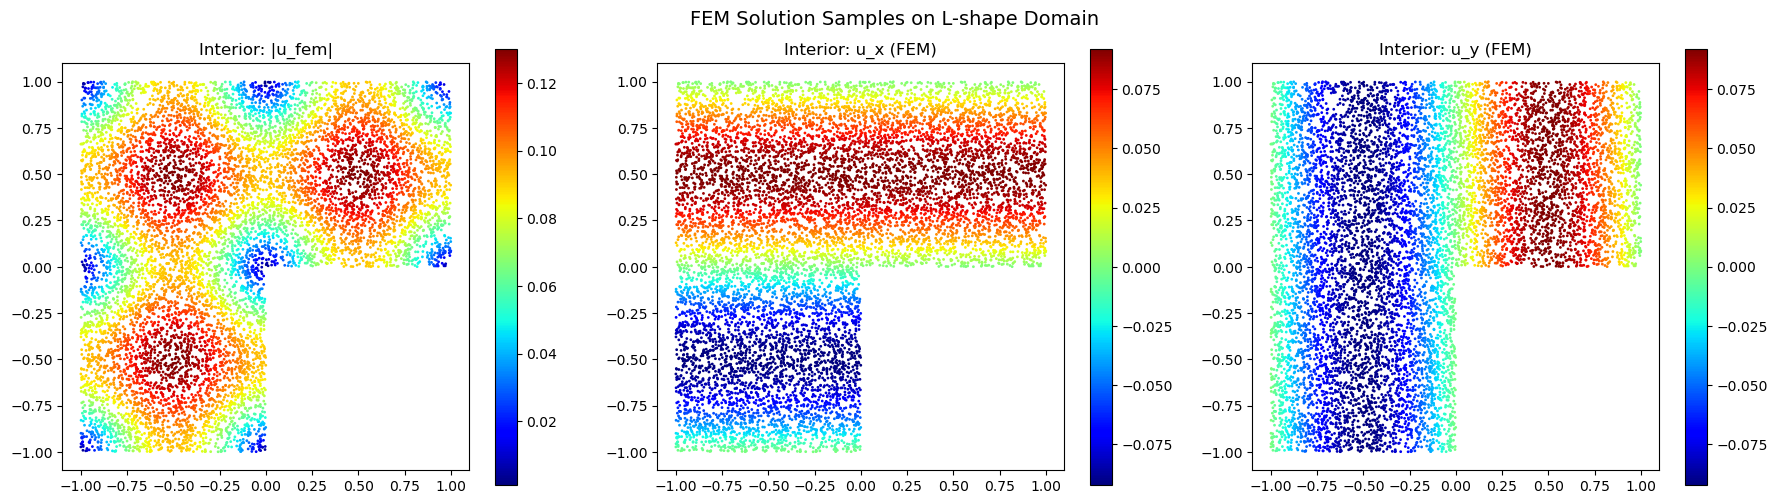

In [ ]:
# ===================== 6. 可视化采样点 =====================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sc0 = axes[0].scatter(x_int[:,0], x_int[:,1], c=np.sqrt(u_int[:,0]**2+u_int[:,1]**2), s=1, cmap='jet')
axes[0].set_title('Interior: |u| (Nédélec FEM)'); axes[0].set_aspect('equal'); plt.colorbar(sc0, ax=axes[0])

sc1 = axes[1].scatter(x_int[:,0], x_int[:,1], c=u_int[:,0], s=1, cmap='jet')
axes[1].set_title(r'Interior: $u_x$ (Nédélec FEM)'); axes[1].set_aspect('equal'); plt.colorbar(sc1, ax=axes[1])

sc2 = axes[2].scatter(x_int[:,0], x_int[:,1], c=u_int[:,1], s=1, cmap='jet')
axes[2].set_title(r'Interior: $u_y$ (Nédélec FEM)'); axes[2].set_aspect('equal'); plt.colorbar(sc2, ax=axes[2])

plt.suptitle('Nédélec FEM Solution Samples on L-shape Domain', fontsize=14)
plt.tight_layout(); plt.show()


---
## Part 2: PINN 求解 (以 Nédélec FEM 解为 Ground Truth)

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

data = np.load('fem_curlcurl_data.npz')
x_col = torch.tensor(data['x_int'], dtype=torch.float32).to(device)
u_fem = torch.tensor(data['u_int'], dtype=torch.float32).to(device)
f_rhs = torch.tensor(data['f_int'], dtype=torch.float32).to(device)
x_bc  = torch.tensor(data['x_bnd'], dtype=torch.float32).to(device)
u_bc_true = torch.tensor(data['u_bnd'], dtype=torch.float32).to(device)

print(f'Interior points: {x_col.shape}, Boundary points: {x_bc.shape}')


Using device: cuda
Interior points: torch.Size([10000, 2]), Boundary points: torch.Size([3000, 2])


In [3]:
# ===================== PINN 网络 =====================
class CubicReLU(nn.Module):
    def forward(self, x):
        return torch.pow(torch.relu(x), 3)

class VectorPINN(nn.Module):
    def __init__(self, activation_name='tanh', hidden_dim=128, n_layers=4):
        super().__init__()
        self.activation_name = activation_name
        if activation_name == 'tanh': act = nn.Tanh()
        elif activation_name == 'relu3': act = CubicReLU()
        elif activation_name == 'gelu': act = nn.GELU()
        else: act = nn.Tanh()
        
        layers = [nn.Linear(2, hidden_dim), act]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), act]
        layers.append(nn.Linear(hidden_dim, 2))
        self.net = nn.Sequential(*layers)
        
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        return self.net(x)


In [ ]:
# ===================== PDE 残差: curl curl u + u - f = 0 =====================
#
# 在 2D 中, u = (u₁, u₂):
#   curl u (标量) = ∂u₂/∂x - ∂u₁/∂y
#   curl curl u (向量) = (∂(curl u)/∂y, -∂(curl u)/∂x)
#
# 因此 PDE 残差:
#   res_x = ∂(curl u)/∂y + u₁ - f₁ = 0
#   res_y = -∂(curl u)/∂x + u₂ - f₂ = 0

def curlcurl_residual(model, x_in, f_rhs):
    x_in = x_in.detach().requires_grad_(True)
    u = model(x_in)
    u1, u2 = u[:, 0:1], u[:, 1:2]
    
    # 计算 grad u₁ 和 grad u₂
    grad_u1 = torch.autograd.grad(u1, x_in, torch.ones_like(u1), create_graph=True)[0]
    grad_u2 = torch.autograd.grad(u2, x_in, torch.ones_like(u2), create_graph=True)[0]
    du1_dy = grad_u1[:, 1:2]  # ∂u₁/∂y
    du2_dx = grad_u2[:, 0:1]  # ∂u₂/∂x
    
    # 标量 curl: curl u = ∂u₂/∂x - ∂u₁/∂y
    scalar_curl = du2_dx - du1_dy
    
    # curl curl u 需要对标量 curl 再取梯度
    grad_curl = torch.autograd.grad(scalar_curl, x_in, torch.ones_like(scalar_curl), create_graph=True)[0]
    # grad_curl[:, 0] = ∂(curl u)/∂x
    # grad_curl[:, 1] = ∂(curl u)/∂y
    
    # curl curl u = (∂(curl u)/∂y, -∂(curl u)/∂x)
    # PDE: curl curl u + u = f
    res_x =  grad_curl[:, 1:2] + u1 - f_rhs[:, 0:1]   # ∂(curl u)/∂y + u₁ - f₁
    res_y = -grad_curl[:, 0:1] + u2 - f_rhs[:, 1:2]   # -∂(curl u)/∂x + u₂ - f₂
    return res_x, res_y


In [5]:
# ===================== 训练 Phase 1 =====================
ACT_TYPE = 'tanh'
model = VectorPINN(ACT_TYPE, hidden_dim=128, n_layers=4).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5000, gamma=0.5)

w_pde, w_bc, w_data = 1.0, 50.0, 1.0
loss_history = []

print(f'--- Training PINN ({ACT_TYPE}), params={sum(p.numel() for p in model.parameters())} ---')
for epoch in range(20001):
    optimizer.zero_grad()
    res_x, res_y = curlcurl_residual(model, x_col, f_rhs)
    loss_pde = torch.mean(res_x**2 + res_y**2)
    loss_bc = torch.mean((model(x_bc) - u_bc_true)**2)
    loss_data = torch.mean((model(x_col) - u_fem)**2)
    loss = w_pde*loss_pde + w_bc*loss_bc + w_data*loss_data
    loss.backward(); optimizer.step(); scheduler.step()
    loss_history.append(loss.item())
    if epoch % 2000 == 0:
        print(f'Epoch {epoch:5d}: Loss={loss.item():.4e} (PDE={loss_pde.item():.3e}, BC={loss_bc.item():.3e}, Data={loss_data.item():.3e})')


--- Training PINN (tanh), params=50178 ---
Epoch     0: Loss=2.1165e+00 (PDE=7.955e-01, BC=2.613e-02, Data=1.447e-02)
Epoch  2000: Loss=9.2992e-04 (PDE=8.658e-04, BC=1.263e-06, Data=9.605e-07)
Epoch  4000: Loss=2.9396e-03 (PDE=8.154e-04, BC=4.197e-05, Data=2.595e-05)
Epoch  6000: Loss=3.1306e-04 (PDE=2.929e-04, BC=3.924e-07, Data=5.642e-07)
Epoch  8000: Loss=1.5987e-04 (PDE=1.459e-04, BC=2.705e-07, Data=4.010e-07)
Epoch 10000: Loss=1.1200e-04 (PDE=6.533e-05, BC=9.152e-07, Data=9.119e-07)
Epoch 12000: Loss=2.9370e-05 (PDE=2.413e-05, BC=1.012e-07, Data=1.788e-07)
Epoch 14000: Loss=5.7879e-05 (PDE=1.731e-05, BC=7.957e-07, Data=7.814e-07)
Epoch 16000: Loss=7.6131e-06 (PDE=5.158e-06, BC=4.745e-08, Data=8.280e-08)
Epoch 18000: Loss=1.1665e-05 (PDE=4.493e-06, BC=1.400e-07, Data=1.745e-07)
Epoch 20000: Loss=6.9123e-06 (PDE=3.052e-06, BC=7.558e-08, Data=8.095e-08)


In [6]:
# ===================== 训练 Phase 2 (fine-tune) =====================
optimizer2 = optim.Adam(model.parameters(), lr=1e-4)
scheduler2 = optim.lr_scheduler.StepLR(optimizer2, step_size=5000, gamma=0.5)

for epoch in range(20001, 40001):
    optimizer2.zero_grad()
    res_x, res_y = curlcurl_residual(model, x_col, f_rhs)
    loss_pde = torch.mean(res_x**2 + res_y**2)
    loss_bc = torch.mean((model(x_bc) - u_bc_true)**2)
    loss_data = torch.mean((model(x_col) - u_fem)**2)
    loss = w_pde*loss_pde + w_bc*loss_bc + w_data*loss_data
    loss.backward(); optimizer2.step(); scheduler2.step()
    loss_history.append(loss.item())
    if epoch % 2000 == 0:
        print(f'Epoch {epoch:5d}: Loss={loss.item():.4e} (PDE={loss_pde.item():.3e}, BC={loss_bc.item():.3e}, Data={loss_data.item():.3e})')


Epoch 22000: Loss=4.4951e-06 (PDE=2.343e-06, BC=4.215e-08, Data=4.475e-08)
Epoch 24000: Loss=3.5535e-06 (PDE=1.978e-06, BC=3.071e-08, Data=3.974e-08)
Epoch 26000: Loss=3.0120e-06 (PDE=1.738e-06, BC=2.476e-08, Data=3.583e-08)
Epoch 28000: Loss=2.8456e-06 (PDE=1.508e-06, BC=2.607e-08, Data=3.404e-08)
Epoch 30000: Loss=6.3757e-06 (PDE=1.712e-06, BC=9.104e-08, Data=1.114e-07)
Epoch 32000: Loss=2.1306e-06 (PDE=1.197e-06, BC=1.817e-08, Data=2.559e-08)
Epoch 34000: Loss=2.9791e-06 (PDE=1.194e-06, BC=3.483e-08, Data=4.336e-08)
Epoch 36000: Loss=1.7576e-06 (PDE=9.793e-07, BC=1.514e-08, Data=2.143e-08)
Epoch 38000: Loss=1.6623e-06 (PDE=8.935e-07, BC=1.496e-08, Data=2.081e-08)
Epoch 40000: Loss=1.4640e-06 (PDE=8.109e-07, BC=1.269e-08, Data=1.845e-08)


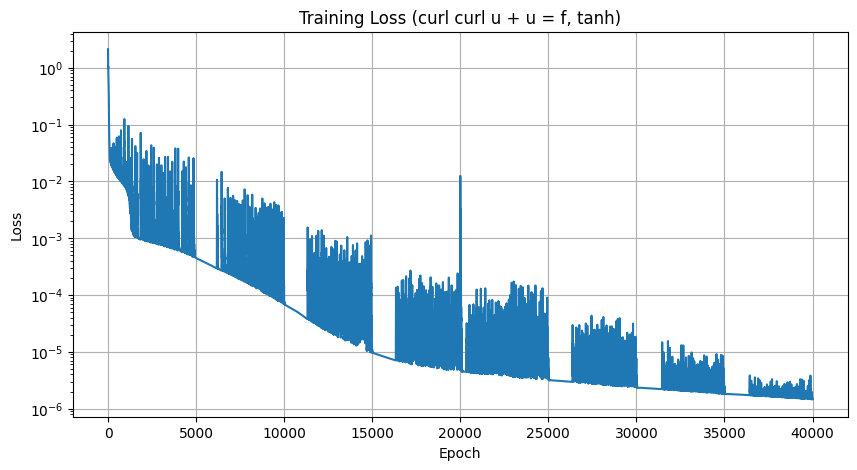

In [7]:
# ===================== Loss 曲线 =====================
plt.figure(figsize=(10, 5))
plt.semilogy(loss_history)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title(f'Training Loss (curl curl u + u = f, {ACT_TYPE})')
plt.grid(True); plt.show()


In [8]:
# ===================== 网格评估函数 =====================
def evaluate_on_grid(model, device, x_range, y_range, n_grid=120):
    xv = np.linspace(x_range[0], x_range[1], n_grid)
    yv = np.linspace(y_range[0], y_range[1], n_grid)
    X, Y = np.meshgrid(xv, yv)
    XY_torch = torch.tensor(np.stack([X.ravel(), Y.ravel()], 1), dtype=torch.float32).to(device)
    mask = (X > 0) & (Y < 0)
    with torch.no_grad():
        U = model(XY_torch).cpu().numpy()
    ux = U[:,0].reshape(n_grid, n_grid); uy = U[:,1].reshape(n_grid, n_grid)
    umag = np.sqrt(ux**2 + uy**2)
    ux[mask]=np.nan; uy[mask]=np.nan; umag[mask]=np.nan
    return X, Y, ux, uy, umag, mask

def evaluate_fem_on_grid(gfu, x_range, y_range, n_grid=120):
    msh = gfu.space.mesh
    xv = np.linspace(x_range[0], x_range[1], n_grid)
    yv = np.linspace(y_range[0], y_range[1], n_grid)
    X, Y = np.meshgrid(xv, yv)
    mask = (X > 0) & (Y < 0)
    ux_f = np.full_like(X, np.nan); uy_f = np.full_like(X, np.nan)
    for i in range(n_grid):
        for j in range(n_grid):
            if X[i,j]>0 and Y[i,j]<0: continue
            try:
                mp = msh(X[i,j], Y[i,j])
                val = gfu(mp)
                ux_f[i,j], uy_f[i,j] = val[0], val[1]
            except: pass
    umag_f = np.sqrt(np.nan_to_num(ux_f)**2 + np.nan_to_num(uy_f)**2)
    umag_f[mask] = np.nan
    return X, Y, ux_f, uy_f, umag_f

print('Evaluating on grid...')
ng = 100
Xp, Yp, uxp, uyp, up, mp = evaluate_on_grid(model, device, (-1,1), (-1,1), ng)
Xf, Yf, uxf, uyf, uf = evaluate_fem_on_grid(gfu, (-1,1), (-1,1), ng)
print('Done!')


Evaluating on grid...


NameError: name 'gfu' is not defined

In [ ]:
# ===================== FEM vs PINN 对比 =====================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

im00 = axes[0,0].contourf(Xf, Yf, uf, levels=50, cmap='jet')
axes[0,0].set_title('Nédélec FEM |u| (Ground Truth)'); axes[0,0].set_aspect('equal'); fig.colorbar(im00, ax=axes[0,0])

im01 = axes[0,1].contourf(Xp, Yp, up, levels=50, cmap='jet')
axes[0,1].set_title(f'PINN |u| ({ACT_TYPE})'); axes[0,1].set_aspect('equal'); fig.colorbar(im01, ax=axes[0,1])

err_mag = np.abs(up - uf)
im02 = axes[0,2].contourf(Xf, Yf, err_mag, levels=50, cmap='inferno')
axes[0,2].set_title('|Error| in |u|'); axes[0,2].set_aspect('equal'); fig.colorbar(im02, ax=axes[0,2])

im10 = axes[1,0].contourf(Xf, Yf, uxf, levels=50, cmap='jet')
axes[1,0].set_title(r'Nédélec FEM $u_x$'); axes[1,0].set_aspect('equal'); fig.colorbar(im10, ax=axes[1,0])

im11 = axes[1,1].contourf(Xp, Yp, uxp, levels=50, cmap='jet')
axes[1,1].set_title(f'PINN $u_x$ ({ACT_TYPE})'); axes[1,1].set_aspect('equal'); fig.colorbar(im11, ax=axes[1,1])

err_ux = np.abs(uxp - uxf)
im12 = axes[1,2].contourf(Xf, Yf, err_ux, levels=50, cmap='inferno')
axes[1,2].set_title(r'|Error| in $u_x$'); axes[1,2].set_aspect('equal'); fig.colorbar(im12, ax=axes[1,2])

plt.suptitle(f'Nédélec FEM vs PINN: curl curl u + u = f on L-shape, ACT={ACT_TYPE}, Epochs={len(loss_history)}', fontsize=14)
plt.tight_layout(); plt.show()

print(f'\n=== Error Statistics ===')
print(f'  Max |u| error:  {np.nanmax(err_mag):.6e}')
print(f'  Mean |u| error: {np.nanmean(err_mag):.6e}')
print(f'  L2 relative:    {np.sqrt(np.nansum(err_mag**2))/np.sqrt(np.nansum(uf**2)):.6e}')


In [ ]:
# ===================== Zoom-in 凹角附近 =====================
print('Evaluating zoom near re-entrant corner...')
nz = 100
Xpz, Ypz, _, _, upz, _ = evaluate_on_grid(model, device, (-0.2,0.2), (-0.2,0.2), nz)
Xfz, Yfz, _, _, ufz = evaluate_fem_on_grid(gfu, (-0.2,0.2), (-0.2,0.2), nz)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
im0 = axes[0].contourf(Xfz, Yfz, ufz, levels=50, cmap='jet')
axes[0].set_title('FEM |u| (Zoom 0.2)'); axes[0].set_aspect('equal'); plt.colorbar(im0, ax=axes[0])
im1 = axes[1].contourf(Xpz, Ypz, upz, levels=50, cmap='jet')
axes[1].set_title('PINN |u| (Zoom 0.2)'); axes[1].set_aspect('equal'); plt.colorbar(im1, ax=axes[1])
err_z = np.abs(upz - ufz)
im2 = axes[2].contourf(Xfz, Yfz, err_z, levels=50, cmap='inferno')
axes[2].set_title('|Error| (Zoom 0.2)'); axes[2].set_aspect('equal'); plt.colorbar(im2, ax=axes[2])
plt.suptitle('Zoom near re-entrant corner', fontsize=14); plt.tight_layout(); plt.show()
print(f'Zoom - Max err: {np.nanmax(err_z):.6e}, Mean err: {np.nanmean(err_z):.6e}')


In [ ]:
# ===================== u_y 分量对比 =====================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
im0 = axes[0].contourf(Xf, Yf, uyf, levels=50, cmap='jet')
axes[0].set_title(r'FEM $u_y$'); axes[0].set_aspect('equal'); plt.colorbar(im0, ax=axes[0])
im1 = axes[1].contourf(Xp, Yp, uyp, levels=50, cmap='jet')
axes[1].set_title(f'PINN $u_y$ ({ACT_TYPE})'); axes[1].set_aspect('equal'); plt.colorbar(im1, ax=axes[1])
err_uy = np.abs(uyp - uyf)
im2 = axes[2].contourf(Xf, Yf, err_uy, levels=50, cmap='inferno')
axes[2].set_title(r'|Error| in $u_y$'); axes[2].set_aspect('equal'); plt.colorbar(im2, ax=axes[2])
plt.suptitle(r'$u_y$ component comparison', fontsize=14); plt.tight_layout(); plt.show()


In [ ]:
# ===================== 保存模型 & 汇总 =====================
torch.save({'model_state_dict': model.state_dict(), 'activation': ACT_TYPE,
            'loss_history': loss_history, 'epochs': len(loss_history)}, 'pinn_curlcurl_model.pth')

print(f'\n{"="*50}')
print(f'Final Results Summary')
print(f'{"="*50}')
print(f'  Equation: curl curl u + u = f')
print(f'  Domain: L-shape [-1,1]² \\ [0,1]×[-1,0]')
print(f'  FEM: Nédélec edge elements (HCurl), order=2')
print(f'  BC: u × n = 0 (tangential homogeneous)')
print(f'  f = (sin(πy), sin(πx))')
print(f'  Activation: {ACT_TYPE}')
print(f'  Total epochs: {len(loss_history)}')
print(f'  Final loss: {loss_history[-1]:.6e}')
print(f'  Max |u| error:  {np.nanmax(err_mag):.6e}')
print(f'  Mean |u| error: {np.nanmean(err_mag):.6e}')
print(f'  L2 relative:    {np.sqrt(np.nansum(err_mag**2))/np.sqrt(np.nansum(uf**2)):.6e}')
